In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (14,7)
plt.rcParams["font.size"] = 12

In [2]:
DATA_DIR = "/home/yousef/Documents/testing_scripts/GEVernova/Fi_Wo_Ca_Dy/Dynamic/Dyn_Files/b200_dynamic_range_max_pulses_BigRange/"

RAW_CSV = DATA_DIR + "dynamic_range_max_raw_measurements.csv"
POINTS_CSV = DATA_DIR + "dynamic_range_max_aggregated_points.csv"
SUMMARY_CSV = DATA_DIR + "dynamic_range_max_summary.csv"

raw_df = pd.read_csv(RAW_CSV)
points_df = pd.read_csv(POINTS_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)

In [3]:
print(raw_df.shape)
print(points_df.shape)
print(summary_df.shape)


(216300, 20)
(18300, 19)
(300, 15)


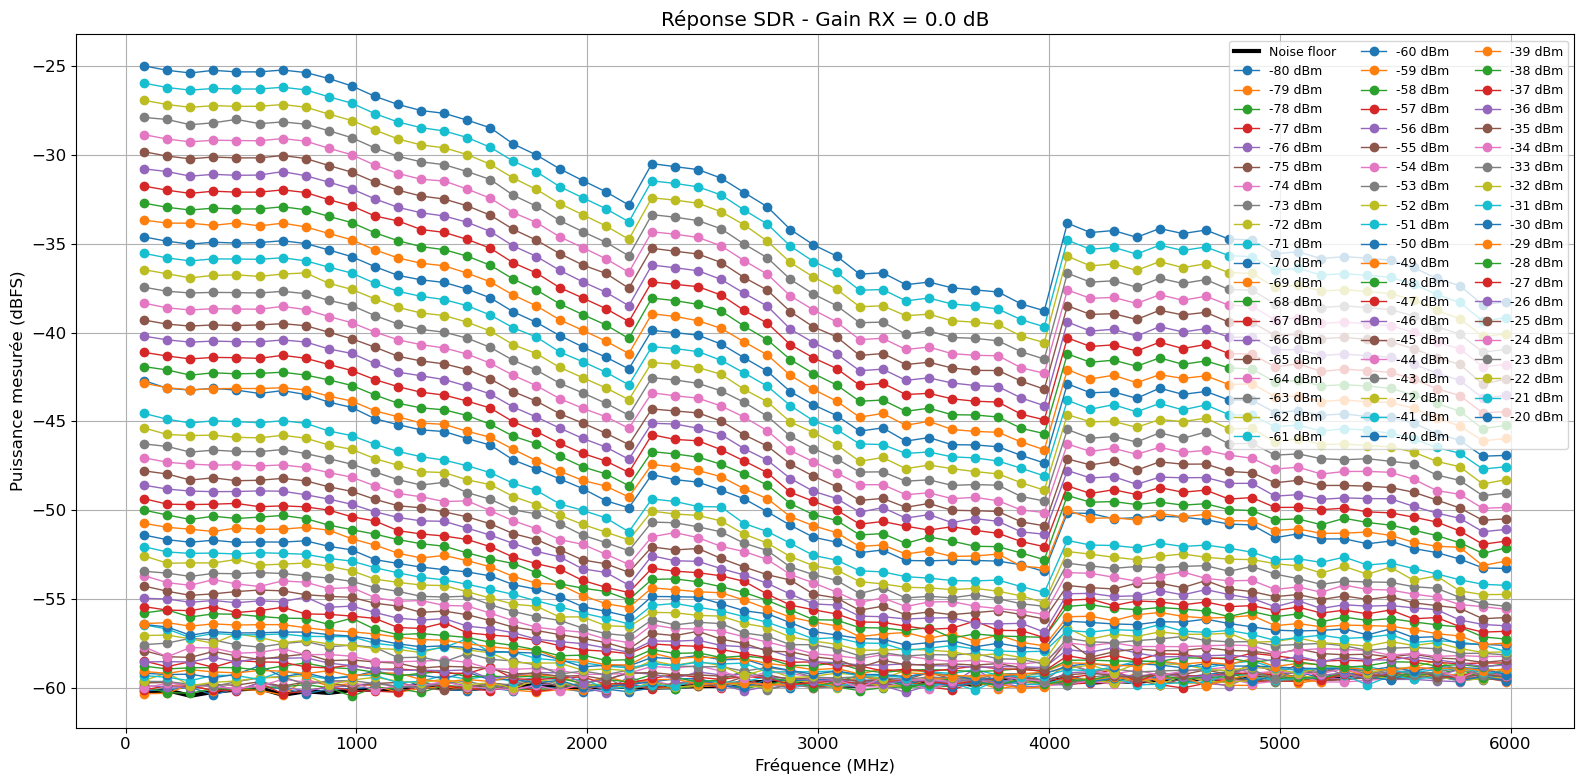

In [4]:
GAIN = 0.0

gain_points = points_df[
    points_df["gain_db"] == GAIN
].copy()

gain_summary = summary_df[
    summary_df["gain_db"] == GAIN
].copy()

gain_points = gain_points.sort_values(
    ["input_rx2_dbm","frequency_mhz"]
)

gain_summary = gain_summary.sort_values(
    "frequency_mhz"
)

plt.figure(figsize=(16,8))

##########################################
# Noise floor
##########################################

plt.plot(
    gain_summary["frequency_mhz"],
    gain_summary["noise_max_dbfs"],
    color="black",
    linewidth=3,
    label="Noise floor"
)

##########################################
# Toutes les puissances injectées
##########################################

levels = sorted(
    gain_points["input_rx2_dbm"].unique()
)

for level in levels:

    df = gain_points[
        gain_points["input_rx2_dbm"] == level
    ]

    plt.plot(
        df["frequency_mhz"],
        df["max_dbfs"],
        marker="o",
        linewidth=1,
        markersize=6,
        label=f"{level:.0f} dBm"
    )

plt.title(f"Réponse SDR - Gain RX = {GAIN} dB")

plt.xlabel("Fréquence (MHz)")
plt.ylabel("Puissance mesurée (dBFS)")

plt.grid(True)

plt.legend(
    ncol=3,
    fontsize=9
)

plt.tight_layout()
plt.show()

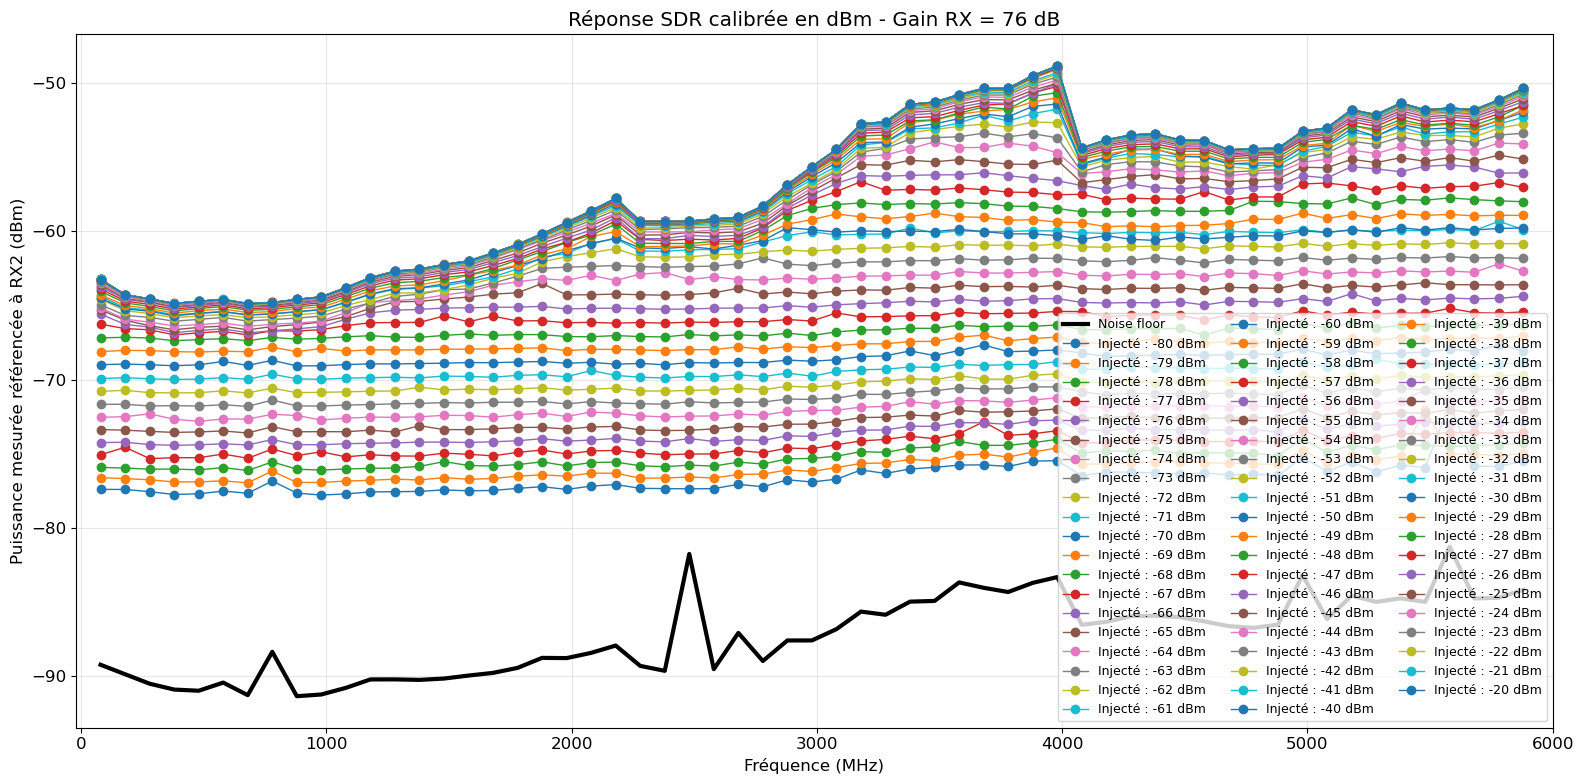

In [9]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

GAIN = 76.0

MAX_FREQ_MHZ = 5900.0

CAL_FILE = Path(
    "/home/yousef/Documents/testing_scripts/GEVernova/"
    "Fi_Wo_Ca_Dy/Calib/Cal_Files/"
    "rx2_power_calibration_final.pickle"
)


# ============================================================
# CHARGEMENT DE LA TABLE DE CALIBRATION
# ============================================================

with CAL_FILE.open("rb") as f:
    calibration = pickle.load(f)

cal_table = calibration[0]["RX2"]


# ============================================================
# FONCTION DE CONVERSION dBFS -> dBm
# ============================================================

def dbfs_to_dbm(
    dbfs,
    frequency_mhz,
    gain_db,
):
    """
    Conversion dBFS -> dBm à partir de la table de calibration.

    Si la fréquence n'existe pas exactement dans la table,
    interpolation linéaire entre les fréquences calibrées voisines.
    """

    frequency_hz = float(frequency_mhz) * 1e6
    gain_db = float(gain_db)

    # Fréquences disponibles dans la calibration pour ce gain
    available_freqs = sorted(
        float(freq_hz)
        for freq_hz, gain_table in cal_table.items()
        if gain_db in gain_table
    )

    if not available_freqs:
        raise ValueError(
            f"Gain {gain_db:.0f} dB absent de la calibration."
        )

    available_freqs = np.asarray(
        available_freqs,
        dtype=float,
    )

    references = np.asarray(
        [
            float(
                cal_table[freq_hz][gain_db]
            )
            for freq_hz in available_freqs
        ],
        dtype=float,
    )

    if (
        frequency_hz < available_freqs.min()
        or frequency_hz > available_freqs.max()
    ):
        return np.nan

    # Référence interpolée selon la fréquence
    reference_dbm = np.interp(
        frequency_hz,
        available_freqs,
        references,
    )

    # Conversion UHD
    return float(dbfs) + float(reference_dbm)


# ============================================================
# SELECTION DU GAIN
# ============================================================

gain_points = points_df[
    np.isclose(
        points_df["gain_db"],
        GAIN,
        atol=0.1,
    )
].copy()

gain_summary = summary_df[
    np.isclose(
        summary_df["gain_db"],
        GAIN,
        atol=0.1,
    )
].copy()


# ============================================================
# LIMITATION A 5.9 GHz
# ============================================================

gain_points = gain_points[
    gain_points["frequency_mhz"]
    <= MAX_FREQ_MHZ
].copy()

gain_summary = gain_summary[
    gain_summary["frequency_mhz"]
    <= MAX_FREQ_MHZ
].copy()


# ============================================================
# TRI
# ============================================================

gain_points = gain_points.sort_values(
    [
        "input_rx2_dbm",
        "frequency_mhz",
    ]
)

gain_summary = gain_summary.sort_values(
    "frequency_mhz"
)


# ============================================================
# CONVERSION DES MESURES EN dBm
# ============================================================

gain_points["max_dbm_calibrated"] = (
    gain_points.apply(
        lambda row: dbfs_to_dbm(
            dbfs=row["max_dbfs"],
            frequency_mhz=row["frequency_mhz"],
            gain_db=GAIN,
        ),
        axis=1,
    )
)


gain_summary["noise_max_dbm_calibrated"] = (
    gain_summary.apply(
        lambda row: dbfs_to_dbm(
            dbfs=row["noise_max_dbfs"],
            frequency_mhz=row["frequency_mhz"],
            gain_db=GAIN,
        ),
        axis=1,
    )
)


# Supprimer uniquement les valeurs hors calibration
gain_points = gain_points.dropna(
    subset=[
        "max_dbm_calibrated"
    ]
)

gain_summary = gain_summary.dropna(
    subset=[
        "noise_max_dbm_calibrated"
    ]
)


# ============================================================
# AFFICHAGE
# ============================================================

plt.figure(
    figsize=(16, 8)
)


# ============================================================
# NOISE FLOOR
# ============================================================

plt.plot(
    gain_summary["frequency_mhz"],
    gain_summary["noise_max_dbm_calibrated"],
    color="black",
    linewidth=3,
    label="Noise floor",
)


# ============================================================
# TOUTES LES PUISSANCES INJECTEES
# ============================================================

levels = sorted(
    gain_points[
        "input_rx2_dbm"
    ].dropna().unique()
)


for level in levels:

    level_df = gain_points[
        np.isclose(
            gain_points["input_rx2_dbm"],
            level,
        )
    ]

    plt.plot(
        level_df["frequency_mhz"],
        level_df["max_dbm_calibrated"],
        marker="o",
        linewidth=1,
        markersize=6,
        label=f"Injecté : {level:.0f} dBm",
    )


# ============================================================
# MISE EN FORME
# ============================================================

plt.title(
    f"Réponse SDR calibrée en dBm - Gain RX = {GAIN:.0f} dB"
)

plt.xlabel(
    "Fréquence (MHz)"
)

plt.ylabel(
    "Puissance mesurée référencée à RX2 (dBm)"
)

# Limite affichage à 5.9 GHz
plt.xlim(
    gain_points["frequency_mhz"].min()-100,
    6000,
)

plt.grid(
    True,
    alpha=0.3,
)

plt.legend(
    ncol=3,
    fontsize=9,
)

plt.tight_layout()

plt.show()

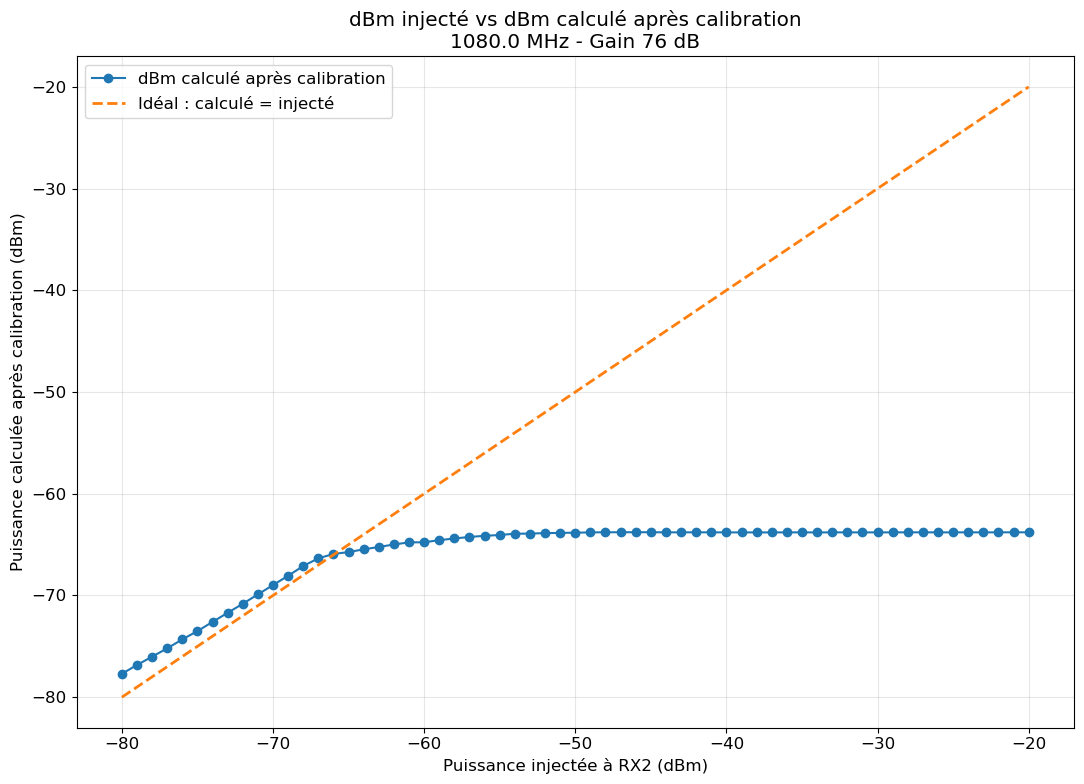

In [13]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

GAIN = 76.0
FREQUENCY_MHZ = 1080.0

CAL_FILE = Path(
    "/home/yousef/Documents/testing_scripts/GEVernova/"
    "Fi_Wo_Ca_Dy/Calib/Cal_Files/"
    "rx2_power_calibration_final.pickle"
)


# ============================================================
# CHARGEMENT DE LA CALIBRATION
# ============================================================

with CAL_FILE.open("rb") as f:
    calibration = pickle.load(f)

cal_table = calibration[0]["RX2"]


# ============================================================
# FONCTION DBFS -> DBM
# ============================================================

def dbfs_to_dbm(dbfs, frequency_mhz, gain_db):

    frequency_hz = float(frequency_mhz) * 1e6
    gain_db = float(gain_db)

    available_freqs = np.array(
        sorted(
            float(freq_hz)
            for freq_hz, gain_table in cal_table.items()
            if gain_db in gain_table
        ),
        dtype=float,
    )

    if len(available_freqs) == 0:
        raise ValueError(
            f"Gain {gain_db:.0f} dB absent de la calibration"
        )

    references = np.array(
        [
            float(cal_table[freq_hz][gain_db])
            for freq_hz in available_freqs
        ],
        dtype=float,
    )

    reference_dbm = np.interp(
        frequency_hz,
        available_freqs,
        references,
    )

    return float(dbfs) + float(reference_dbm)


# ============================================================
# SELECTION DU CAS
# ============================================================

case_df = points_df[
    np.isclose(
        points_df["gain_db"],
        GAIN,
        atol=0.1,
    )
    &
    np.isclose(
        points_df["frequency_mhz"],
        FREQUENCY_MHZ,
        atol=1e-6,
    )
].copy()


if case_df.empty:
    raise ValueError(
        f"Aucune donnée pour {FREQUENCY_MHZ:.1f} MHz "
        f"et gain {GAIN:.0f} dB"
    )


case_df = case_df.sort_values(
    "input_rx2_dbm"
).reset_index(drop=True)


# ============================================================
# CONVERSION APRES CALIBRATION
# ============================================================

case_df["calculated_dbm"] = (
    case_df["max_dbfs"].apply(
        lambda dbfs: dbfs_to_dbm(
            dbfs,
            FREQUENCY_MHZ,
            GAIN,
        )
    )
)


# ============================================================
# GRAPHE
# ============================================================

plt.figure(figsize=(11, 8))

plt.plot(
    case_df["input_rx2_dbm"],
    case_df["calculated_dbm"],
    marker="o",
    linewidth=1.5,
    label="dBm calculé après calibration",
)


# Droite idéale y = x
minimum = min(
    case_df["input_rx2_dbm"].min(),
    case_df["calculated_dbm"].min(),
)

maximum = max(
    case_df["input_rx2_dbm"].max(),
    case_df["calculated_dbm"].max(),
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=2,
    label="Idéal : calculé = injecté",
)


plt.title(
    f"dBm injecté vs dBm calculé après calibration\n"
    f"{FREQUENCY_MHZ:.1f} MHz - Gain {GAIN:.0f} dB"
)

plt.xlabel(
    "Puissance injectée à RX2 (dBm)"
)

plt.ylabel(
    "Puissance calculée après calibration (dBm)"
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()